In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
results_df = pd.read_csv("../data/processed/capm_results.csv")

results_df.head()

,Stock,Alpha,Beta,Alpha_p,Beta_p,R2,Sector
0,AAPL,0.000451,1.203310,0.050055,0.000000e+00,0.558030,Information Technology
1,ABBV,0.000407,0.653133,0.155796,3.094928e-131,0.193653,Health Care
2,BAC,0.000083,1.209051,0.750442,0.000000e+00,0.495953,Financials
3,CAT,0.000415,1.072111,0.133030,0.000000e+00,0.410417,Industrials
4,COP,-0.000017,1.118597,0.965281,1.338724e-197,0.278052,Energy


In [3]:
results_df.describe()

,Alpha,Beta,Alpha_p,Beta_p,R2
count,30.000000,30.000000,30.000000,3.000000e+01,30.000000
mean,0.000241,0.931660,0.450739,4.013425e-122,0.369649
std,0.000367,0.288713,0.363678,2.198148e-121,0.138280
min,-0.000420,0.492669,0.000092,0.000000e+00,0.179307
25%,0.000003,0.662512,0.136147,0.000000e+00,0.267639
50%,0.000179,0.992708,0.376264,5.666831e-239,0.334115
75%,0.000396,1.120068,0.780111,2.712793e-186,0.500686
max,0.001693,1.758900,0.987409,1.203977e-120,0.623037


In [4]:
print("Highest Beta Stocks")
display(results_df.sort_values("Beta", ascending=False).head())

print("Lowest Beta Stocks")
display(results_df.sort_values("Beta").head())

Highest Beta Stocks


,Stock,Alpha,Beta,Alpha_p,Beta_p,R2,Sector
20,NVDA,0.001693,1.758900,0.000092,0.0,0.433020,Information Technology
2,BAC,0.000083,1.209051,0.750442,0.0,0.495953,Financials
0,AAPL,0.000451,1.203310,0.050055,0.0,0.558030,Information Technology
10,GS,0.000201,1.203233,0.391133,0.0,0.550155,Financials
19,MSFT,0.000467,1.185112,0.018439,0.0,0.623037,Information Technology


Lowest Beta Stocks


,Stock,Alpha,Beta,Alpha_p,Beta_p,R2,Sector
12,JNJ,0.000141,0.492669,0.460611,7.688923e-163,0.235005,Health Care
28,WMT,0.000365,0.516943,0.116819,5.047895e-125,0.185267,Consumer Staples
14,KO,0.000067,0.535481,0.707092,6.250468e-209,0.291555,Consumer Staples
18,MRK,0.000158,0.555431,0.515106,2.733797e-132,0.195067,Health Care
22,PEP,0.000022,0.579065,0.909029,2.176029e-213,0.296799,Consumer Staples


In [5]:
sector_beta = (
    results_df
    .groupby("Sector")["Beta"]
    .mean()
    .sort_values(ascending=False)
)

sector_beta

Sector
Information Technology    1.292711
Communication Services    1.141315
Financials                1.132318
Energy                    1.013406
Industrials               0.988902
Consumer Discretionary    0.636829
Health Care               0.598251
Consumer Staples          0.584109
Name: Beta, dtype: float64

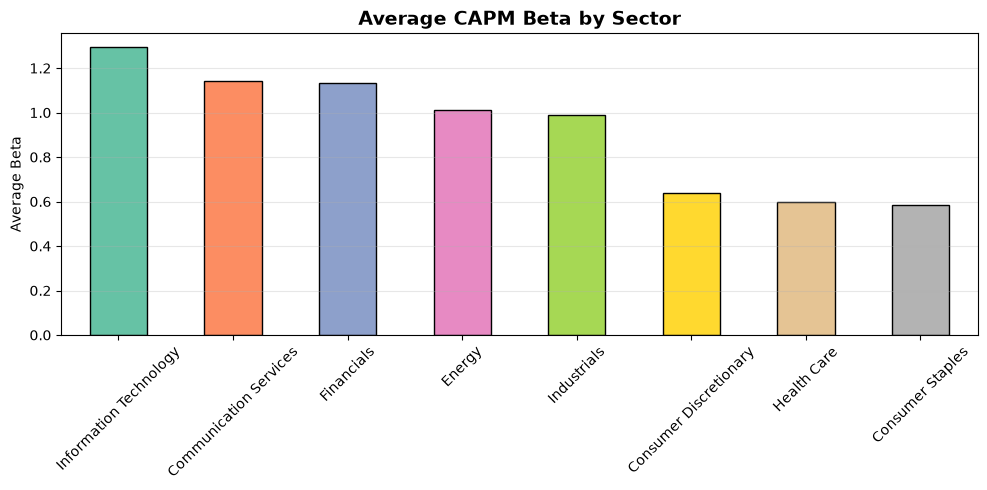

In [11]:
plt.figure(figsize=(10,5))

colors = plt.cm.Set2(range(len(sector_beta)))

sector_beta.plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)

plt.title("Average CAPM Beta by Sector", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Average Beta")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
sector_r2 = (
    results_df
    .groupby("Sector")["R2"]
    .mean()
    .sort_values(ascending=False)
)

sector_r2

Sector
Financials                0.545808
Communication Services    0.502263
Information Technology    0.484976
Industrials               0.412817
Consumer Discretionary    0.317135
Energy                    0.281836
Consumer Staples          0.279009
Health Care               0.202370
Name: R2, dtype: float64

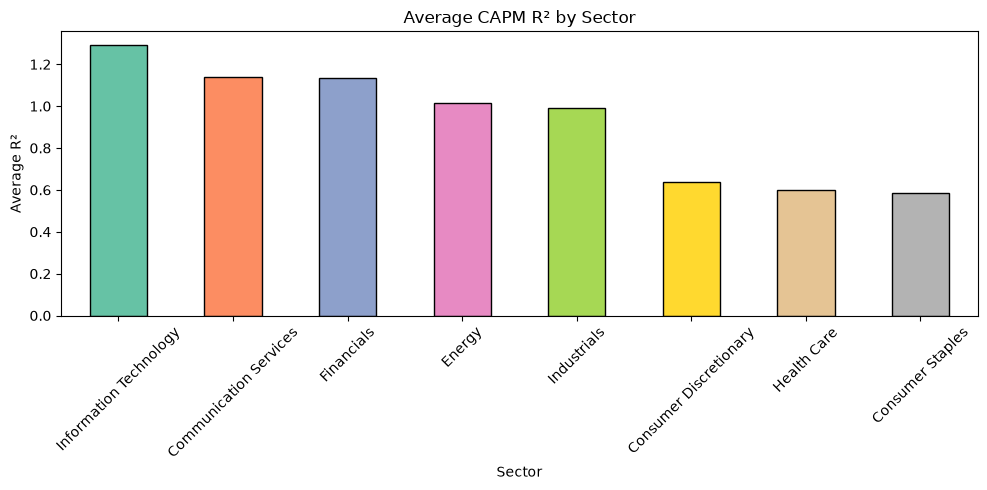

In [12]:
plt.figure(figsize=(10,5))
colors = plt.cm.Set2(range(len(sector_beta)))

sector_beta.plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)


plt.ylabel("Average R²")
plt.title("Average CAPM R² by Sector")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [9]:
significant = results_df[results_df["Alpha_p"] < 0.05]

print(significant[["Stock", "Alpha", "Alpha_p"]])
print(f"\nNumber of significant alphas: {len(significant)}")

    Stock     Alpha   Alpha_p
5    COST  0.000443  0.034847
9   GOOGL  0.000504  0.038910
15    LLY  0.000863  0.006609
19   MSFT  0.000467  0.018439
20   NVDA  0.001693  0.000092

Number of significant alphas: 5


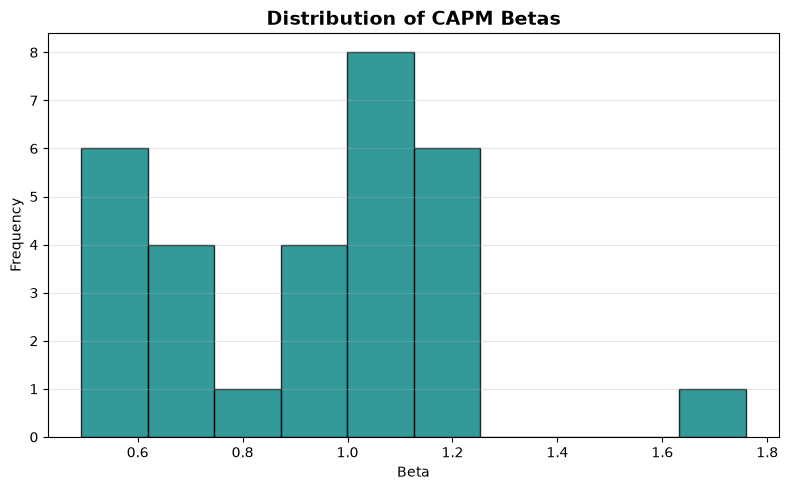

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    results_df["Beta"],
    bins=10,
    color="teal",      # or any color you like
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of CAPM Betas", fontsize=14, weight="bold")
plt.xlabel("Beta")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()